# Import

In [699]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\hp\Desktop\works\donnees\modele_3966_Aug_Dec2025.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

print(df.shape)
print(df.index.min(), '->', df.index.max())
df.head()

(3501, 13)
2025-08-08 03:00:00+00:00 -> 2025-12-31 23:00:00+00:00


,P0,P1,P2,humidity,temperature,heure,jour_semaine,periode,P2_lag_1,P2_lag_2,P2_lag_3,P2_lag_24,P2_lag_168
timestamp,,,,,,,,,,,,,
2025-08-08 03:00:00+00:00,22.111431,36.489514,30.930691,84.350000,15.250000,3,Friday,semaine,33.375576,35.820461,38.265346,13.900000,34.6650
2025-08-08 04:00:00+00:00,23.508573,40.748386,32.879269,72.721523,18.704283,4,Friday,semaine,30.930691,33.375576,35.820461,18.950000,31.8325
2025-08-08 05:00:00+00:00,24.905715,45.007257,34.827846,61.093046,22.158567,5,Friday,semaine,32.879269,30.930691,33.375576,24.000000,29.0000
2025-08-08 06:00:00+00:00,24.704000,50.080000,35.366000,51.743310,25.460561,6,Friday,semaine,34.827846,32.879269,30.930691,21.427846,24.0000
2025-08-08 07:00:00+00:00,40.081250,70.162500,54.506250,51.725000,25.150000,7,Friday,semaine,35.366000,34.827846,32.879269,24.236138,23.1000


In [700]:
df.columns

Index(['P0', 'P1', 'P2', 'humidity', 'temperature', 'heure', 'jour_semaine',
       'periode', 'P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24',
       'P2_lag_168'],
      dtype='object')

In [701]:
# Créer les lags de 1 à 10 pour P2
for i in range(1, 6):
    df[f'P2_lag_{i}'] = df['P2'].shift(i)

# Vérifier les nouvelles colonnes
print("Nouvelles colonnes créées :")
print([col for col in df.columns if 'P2_lag_' in col])

# Afficher les 15 premières lignes pour voir le décalage
df[[f'P2_lag_{i}' for i in range(1, 6)] + ['P2']].head(15)

Nouvelles colonnes créées :
['P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24', 'P2_lag_168', 'P2_lag_4', 'P2_lag_5']


,P2_lag_1,P2_lag_2,P2_lag_3,P2_lag_4,P2_lag_5,P2
timestamp,,,,,,
2025-08-08 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,30.930691
2025-08-08 04:00:00+00:00,30.930691,NaN,NaN,NaN,NaN,32.879269
2025-08-08 05:00:00+00:00,32.879269,30.930691,NaN,NaN,NaN,34.827846
2025-08-08 06:00:00+00:00,34.827846,32.879269,30.930691,NaN,NaN,35.366000
2025-08-08 07:00:00+00:00,35.366000,34.827846,32.879269,30.930691,NaN,54.506250
2025-08-08 08:00:00+00:00,54.506250,35.366000,34.827846,32.879269,30.930691,64.137277
2025-08-08 09:00:00+00:00,64.137277,54.506250,35.366000,34.827846,32.879269,57.071596
2025-08-08 10:00:00+00:00,57.071596,64.137277,54.506250,35.366000,34.827846,55.231138
2025-08-08 11:00:00+00:00,55.231138,57.071596,64.137277,54.506250,35.366000,50.280198


In [702]:
df.columns

Index(['P0', 'P1', 'P2', 'humidity', 'temperature', 'heure', 'jour_semaine',
       'periode', 'P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24',
       'P2_lag_168', 'P2_lag_4', 'P2_lag_5'],
      dtype='object')

In [703]:
# Supprimer les premières lignes avec NaN
print(f"Lignes avant : {len(df)}")
df = df.dropna(subset=[f'P2_lag_{i}' for i in range(1, 6)])


print(f"Lignes après drop : {len(df)}")

Lignes avant : 3501
Lignes après drop : 3496


In [704]:
df['periode'] = (df['periode'] == 'weekend').astype(int)



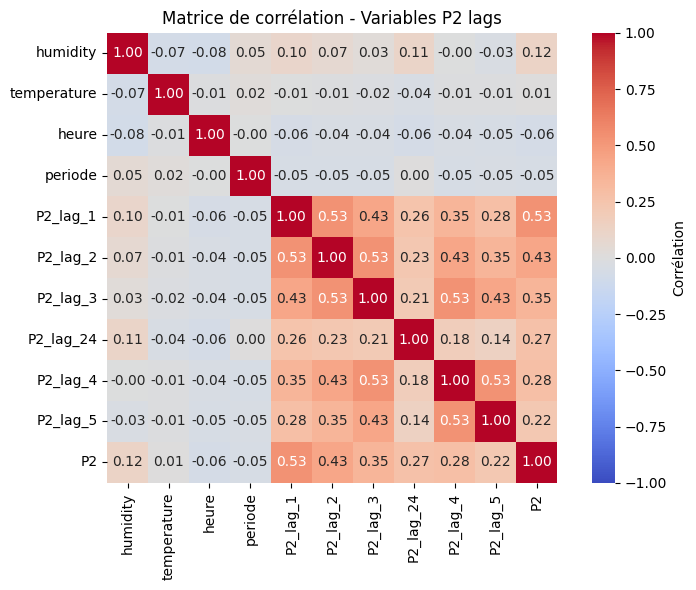

In [705]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sélectionner les colonnes de lag
lag_columns = ['humidity', 'temperature', 'heure', 'periode', 'P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24', 'P2_lag_4', 'P2_lag_5',
'P2']

# Créer une copie avec seulement ces colonnes (supprimer les NaN)
df_lags = df[lag_columns].dropna()

# Calculer la matrice de corrélation
correlation_matrix = df_lags.corr()

# Créer la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True,           # Afficher les valeurs
            cmap='coolwarm',      # Dégradé de couleurs
            center=0,             # Centre le dégradé sur 0
            vmin=-1, vmax=1,      # Bornes de corrélation
            square=True,          # Cellules carrées
            fmt='.2f',            # Format des nombres (2 décimales)
            cbar_kws={'label': 'Corrélation'})

plt.title('Matrice de corrélation - Variables P2 lags')
plt.tight_layout()
plt.show()

In [706]:
print(df['P2'].describe())

count    3496.000000
mean       34.159441
std        12.009648
min         9.608333
25%        27.741856
50%        32.822331
75%        38.540570
max       421.310230
Name: P2, dtype: float64


In [707]:
# Réinitialiser l'index pour avoir timestamp comme colonne
df_prophet = df.reset_index()
df_prophet = df_prophet.drop(columns=["jour_semaine",'P2_lag_168'])


# Renommer les colonnes
df_prophet = df_prophet.rename(columns={'timestamp': 'ds', 'P2': 'y'})
df_prophet['jour_semaine'] = pd.to_datetime(df_prophet['ds']).dt.dayofweek

# Créer la cible décalée pour prédire l'heure suivante
df_prophet['y'] = df_prophet['y'].shift(-1)

# Supprimer la dernière ligne (devenue NaN à cause du shift)
df_prophet = df_prophet.dropna(subset=['y'])

liste_non_regresseur = [
   'temperature', 
    'humidity', 
    'heure', 
    'periode',
    'jour_semaine',
      #      'P2_lag_1', 
            #'P2_lag_2',
            #'P2_lag_3',
              #'P2_lag_4',
           #'P2_lag_5',
       #    'P2_lag_24', 
 ]

#supprimer ce qui ne seras pas regresseur
df_prophet = df_prophet.drop(columns=liste_non_regresseur )

print(df_prophet.head(2))

                         ds         P0         P1          y   P2_lag_1  \
0 2025-08-08 08:00:00+00:00  45.819572  74.470806  57.071596  54.506250   
1 2025-08-08 09:00:00+00:00  39.905715  69.657257  55.231138  64.137277   

   P2_lag_2   P2_lag_3  P2_lag_24   P2_lag_4   P2_lag_5  
0  35.36600  34.827846  28.251626  32.879269  30.930691  
1  54.50625  35.366000  31.060395  34.827846  32.879269  


In [708]:
liste_not_use = liste_non_regresseur+['ds', 'P0', 'P1', 'y']

In [709]:
reg = [column for column in df_prophet.columns if column  not in liste_not_use ]

print(reg)

['P2_lag_1', 'P2_lag_2', 'P2_lag_3', 'P2_lag_24', 'P2_lag_4', 'P2_lag_5']


In [710]:
from prophet import Prophet

# Prendre les mêmes indices que y (donc shiftées)
idx = df_prophet.index  # déjà shifté pour y

df_model = df_prophet.copy()

for regresseur in reg:
    df_model[regresseur] = df[regresseur].iloc[idx].values



In [711]:
print(df_prophet.head(2))

                         ds         P0         P1          y   P2_lag_1  \
0 2025-08-08 08:00:00+00:00  45.819572  74.470806  57.071596  54.506250   
1 2025-08-08 09:00:00+00:00  39.905715  69.657257  55.231138  64.137277   

   P2_lag_2   P2_lag_3  P2_lag_24   P2_lag_4   P2_lag_5  
0  35.36600  34.827846  28.251626  32.879269  30.930691  
1  54.50625  35.366000  31.060395  34.827846  32.879269  


In [712]:
if 'jour_semaine' in reg:
    df_model = df_model.drop(columns=["jour_semaine"])
    df_model['jour_semaine'] = pd.to_datetime(df_model['ds']).dt.dayofweek



In [713]:
df_model.head(2)

,ds,P0,P1,y,P2_lag_1,P2_lag_2,P2_lag_3,P2_lag_24,P2_lag_4,P2_lag_5
0,2025-08-08 08:00:00+00:00,45.819572,74.470806,57.071596,54.506250,35.36600,34.827846,28.251626,32.879269,30.930691
1,2025-08-08 09:00:00+00:00,39.905715,69.657257,55.231138,64.137277,54.50625,35.366000,31.060395,34.827846,32.879269


# Test 1

In [714]:
n_w,n_d=0,0

In [715]:
# Initialiser le modèle
model = Prophet(changepoint_prior_scale=0.5)

for regresseur in reg:
   model.add_regressor(regresseur)




In [716]:
# Garder les 168 dernières heures (7 jours) pour le test
train_size = len(df_model) - 168
df_train = df_model.iloc[:train_size]
df_test = df_model.iloc[train_size:]

print(f"Entraînement : {len(df_train)} lignes")
print(f"Test : {len(df_test)} lignes")
print(f"Période test : {df_test['ds'].min()} -> {df_test['ds'].max()}")
print(df_train.head(2))

Entraînement : 3327 lignes
Test : 168 lignes
Période test : 2025-12-24 23:00:00+00:00 -> 2025-12-31 22:00:00+00:00
                         ds         P0         P1          y   P2_lag_1  \
0 2025-08-08 08:00:00+00:00  45.819572  74.470806  57.071596  54.506250   
1 2025-08-08 09:00:00+00:00  39.905715  69.657257  55.231138  64.137277   

   P2_lag_2   P2_lag_3  P2_lag_24   P2_lag_4   P2_lag_5  
0  35.36600  34.827846  28.251626  32.879269  30.930691  
1  54.50625  35.366000  31.060395  34.827846  32.879269  


In [717]:

# Supprimer le fuseau horaire
df_train['ds'] = df_train['ds'].dt.tz_localize(None)
df_test['ds'] = df_test['ds'].dt.tz_localize(None)



# Après winsorizing


model.fit(df_train)

print("Modèle entraîné avec succès")

C:\Users\hp\AppData\Local\Temp\ipykernel_30260\1622924914.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['ds'] = df_train['ds'].dt.tz_localize(None)
C:\Users\hp\AppData\Local\Temp\ipykernel_30260\1622924914.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['ds'] = df_test['ds'].dt.tz_localize(None)
13:15:12 - cmdstanpy - INFO - Chain [1] start processing
13:15:12 - cmdstanpy - INFO - Chain [1] done processing


Modèle entraîné avec succès


In [718]:
# Créer le DataFrame futur avec les dates de test
future = df_test[['ds']].copy()

# Ajouter les régresseurs pour le futur (ils sont déjà dans df_test)

for regresseur in reg:

    future[regresseur] = df_test[regresseur].values

print(f"Modèle configuré avec {len(reg)} régresseurs")

# Prédire
forecast = model.predict(future)

Modèle configuré avec 6 régresseurs


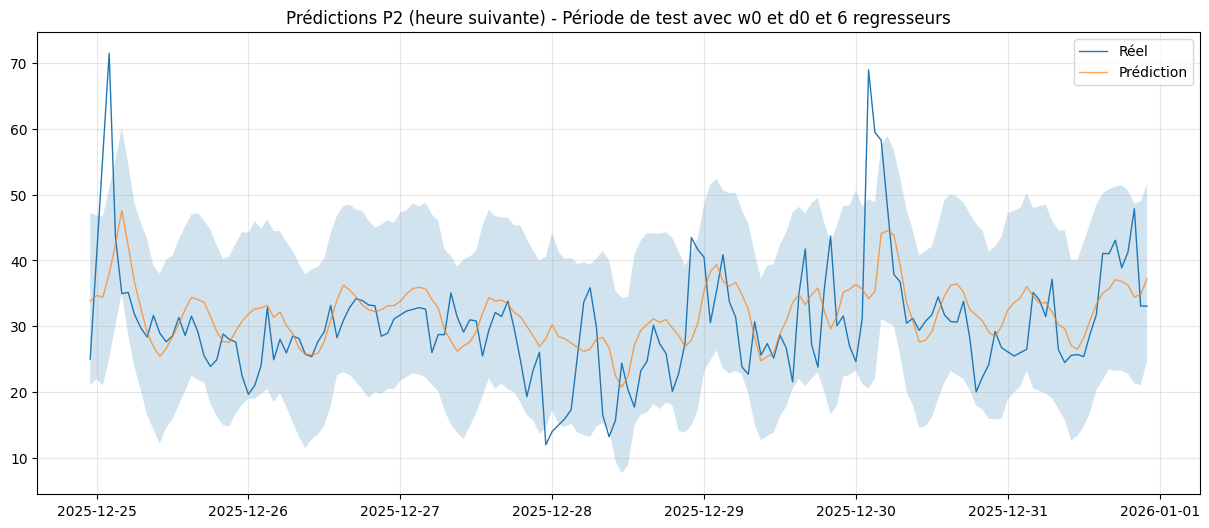

In [719]:
import matplotlib.pyplot as plt

# Fusionner les prédictions avec les vraies valeurs
results = df_test[['ds', 'y']].copy()
results['prediction'] = forecast['yhat'].values

# Tracer
plt.figure(figsize=(15, 6))
plt.plot(results['ds'], results['y'], label='Réel', linewidth=1)
plt.plot(results['ds'], results['prediction'], label='Prédiction', linewidth=1, alpha=0.7)
plt.fill_between(results['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha=0.2)
plt.legend()
plt.title(f'Prédictions P2 (heure suivante) - Période de test avec w{n_w} et d{n_d} et {len(reg)} regresseurs')
plt.grid(True, alpha=0.3)
plt.show()

In [720]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(results['y'], results['prediction'])
rmse = np.sqrt(mean_squared_error(results['y'], results['prediction']))

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE : 5.46
RMSE : 7.65


# Test 2

Modèle configuré avec 6 régresseurs


13:15:13 - cmdstanpy - INFO - Chain [1] start processing
13:15:15 - cmdstanpy - INFO - Chain [1] done processing


Modèle entraîné avec succès
MAE : 6.34
RMSE : 8.39


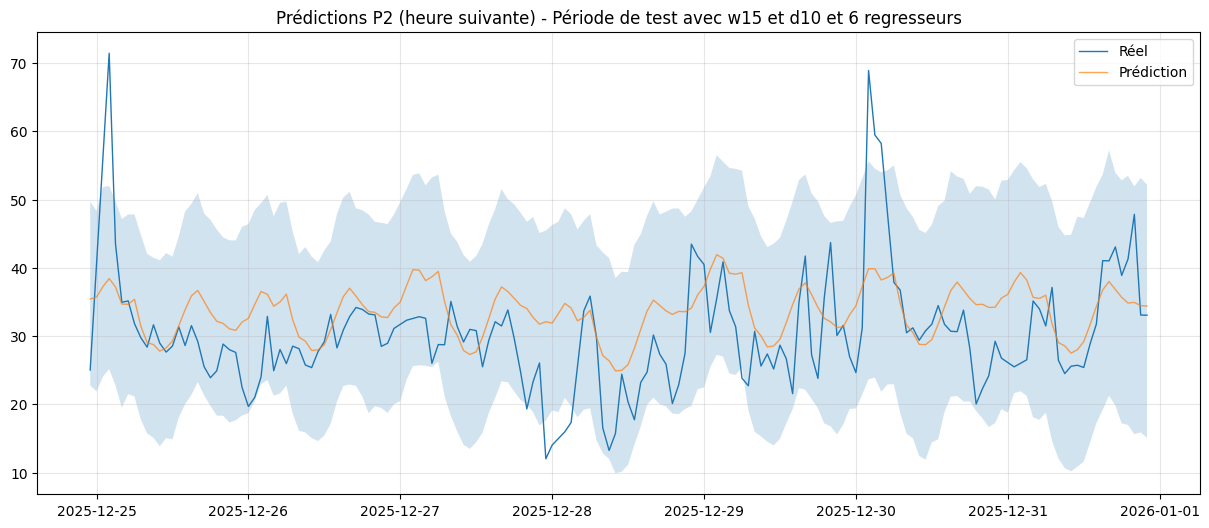

In [721]:
n_w,n_d=15,10
model = Prophet( weekly_seasonality=n_w, daily_seasonality=n_d,changepoint_prior_scale=0.5)

for regresseur in reg:

    future[regresseur] = df_test[regresseur].values

print(f"Modèle configuré avec {len(reg)} régresseurs")

model.fit(df_train)

print("Modèle entraîné avec succès")

# Prédire
forecast = model.predict(future)




import matplotlib.pyplot as plt

# Fusionner les prédictions avec les vraies valeurs
results = df_test[['ds', 'y']].copy()
results['prediction'] = forecast['yhat'].values

mae = mean_absolute_error(results['y'], results['prediction'])
rmse = np.sqrt(mean_squared_error(results['y'], results['prediction']))

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

# Tracer
plt.figure(figsize=(15, 6))
plt.plot(results['ds'], results['y'], label='Réel', linewidth=1)
plt.plot(results['ds'], results['prediction'], label='Prédiction', linewidth=1, alpha=0.7)
plt.fill_between(results['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha=0.2)
plt.legend()
plt.title(f'Prédictions P2 (heure suivante) - Période de test avec w{n_w} et d{n_d} et {len(reg)} regresseurs')
plt.grid(True, alpha=0.3)
plt.show()